# Detecção de Defeitos em PCBs utilizando RetinaNet

>&nbsp;&nbsp;&nbsp;&nbsp;Alexandre Augusto Tescaro Oliveira

## 1. Introdução e Motivação

> **Resumo do Estudo:** Este trabalho apresenta o desenvolvimento de um sistema de Visão Computacional para detecção automática de defeitos em Placas de Circuito Impresso (PCBs), utilizando a arquitetura **RetinaNet**. Para viabilizar a execução local e manter comparação consistente entre modelos, o conjunto de dados anotado no formato COCO foi organizado diretamente sob os arquivos extraídos no *EDA*, preservando a distribuição das classes de defeito.

### 1.1 Contextualização
No cenário da Indústria 4.0, a garantia de qualidade na fabricação de componentes eletrônicos é crítica para reduzir perdas, retrabalho e falhas em campo. As Placas de Circuito Impresso (PCBs) são a base de praticamente todos os dispositivos eletrônicos modernos. Com a miniaturização dos componentes, a inspeção visual tornou-se mais complexa e exige soluções automáticas robustas.

### 1.2 O Problema
Tradicionalmente, a inspeção de PCBs é realizada de forma manual por operadores humanos ou por algoritmos de visão clássica baseados em regras rígidas. Esses métodos apresentam limitações no ambiente industrial:
>* **Fadiga Humana:** A inspeção visual repetitiva aumenta a chance de erro e inconsistências.
>* **Baixa Escalabilidade:** A inspeção manual é lenta e cria gargalos na linha de produção.
>* **Sensibilidade de Regras:** Métodos clássicos falham com variações de iluminação, rotação e ruído.

### 1.3 A Solução Proposta
Para reduzir esses problemas e automatizar o processo de inspeção, este notebook adota Deep Learning com **RetinaNet** (detector de uma etapa com focal loss), otimizado para detecção de objetos pequenos como defeitos em PCBs.

O objetivo é identificar e localizar seis tipos comuns de defeitos de fabricação:
>1.  **Missing Hole** (Furo faltante)
>2.  **Mouse Bite** (Mordida de rato/Falha na borda)
>3.  **Open Circuit** (Circuito aberto)
>4.  **Short** (Curto-circuito)
>5.  **Spur** (Esporão/Rebarba)
>6.  **Spurious Copper** (Cobre residual)


## 2. Análise Exploratória dos Dados (EDA)
> Notebook pode ser encontrado em ./EDA_VC.ipynb

> Link de acesso ao Dataset utilizado: https://www.kaggle.com/datasets/norbertelter/pcb-defect-dataset

> Para o RetinaNet foi necessário adaptar o dataset para o formato COCO, devido à incompatibilidade nativa com a notação de coordenadas do YOLO. Para essa etapa, ao invés de depender de plataformas de terceiros limitadas (como o Roboflow), foi utilizado o conversor customizado open-source **[Yolo-to-COCO-format-converter](https://github.com/alehholiveira/Yolo-to-COCO-format-converter)**. Este fork foi aprimorado para suportar o formato moderno de pastas do YOLO, garantindo que todo o subset gerado na EDA pudesse ser convertido dinamicamente para o padrão JSON lido pelo PyTorch.

In [1]:
import importlib.util
import subprocess
import sys

FORCE_REINSTALL_TORCH = False
PREFER_CUDA_ON_NVIDIA = True
CUDA_INDEX_URL = "https://download.pytorch.org/whl/cu121"

def _run_cmd(args):
    print("$", " ".join(args))
    subprocess.check_call(args)

def _module_exists(module_name):
    return importlib.util.find_spec(module_name) is not None

def _has_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            check=False,
            capture_output=True,
            text=True,
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    except FileNotFoundError:
        return False

def _torch_stack_ready(needs_cuda):
    required_modules = ["torch", "torchvision", "torchaudio"]
    if not all(_module_exists(module_name) for module_name in required_modules):
        return False

    import torch

    if needs_cuda:
        return torch.cuda.is_available() and (torch.version.cuda is not None)
    return True

def _install_torch_stack(needs_cuda):
    install_cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "torch",
        "torchvision",
        "torchaudio",
    ]
    if needs_cuda:
        install_cmd += ["--index-url", CUDA_INDEX_URL]

    try:
        _run_cmd(install_cmd)
    except subprocess.CalledProcessError:
        print("Primeira tentativa falhou. Limpando stack PyTorch e tentando novamente...")
        _run_cmd([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
        _run_cmd(install_cmd)

nvidia_gpu_detected = _has_nvidia_gpu()
needs_cuda = PREFER_CUDA_ON_NVIDIA and nvidia_gpu_detected

# Garante ferramentas básicas de build/instalação no venv recém-criado.
_run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"])

if FORCE_REINSTALL_TORCH or not _torch_stack_ready(needs_cuda):
    target_label = "CUDA 12.1 (cu121)" if needs_cuda else "CPU"
    print(f"Instalando stack PyTorch para {target_label}...")
    _install_torch_stack(needs_cuda)
    print("Stack PyTorch instalada/atualizada.")
else:
    print("Stack PyTorch já compatível com este ambiente.")

required_packages = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "Pillow": "PIL",
    "numpy": "numpy",
    "tqdm": "tqdm",
    "torchmetrics": "torchmetrics",
    "faster-coco-eval": "faster_coco_eval",
    "certifi": "certifi",
}

missing = [pkg for pkg, module in required_packages.items() if not _module_exists(module)]
if missing:
    _run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", *missing])
    print("Dependências instaladas:", ", ".join(missing))
else:
    print("Dependências já instaladas.")

import torch

print(f"Torch: {torch.__version__} | CUDA build: {torch.version.cuda} | cuda_available={torch.cuda.is_available()}")
if needs_cuda and not torch.cuda.is_available():
    print("ATENÇÃO: GPU NVIDIA detectada, mas CUDA indisponível. Reinicie o kernel e execute novamente esta célula.")

$ /home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/bin/python -m pip install --upgrade pip setuptools wheel
Stack PyTorch já compatível com este ambiente.
Dependências já instaladas.
Torch: 2.5.1+cu121 | CUDA build: 12.1 | cuda_available=True


In [2]:
# Diagnóstico rápido do runtime PyTorch
import subprocess
import torch

def _has_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            check=False,
            capture_output=True,
            text=True,
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    except FileNotFoundError:
        return False

nvidia_gpu_detected = _has_nvidia_gpu()

print(f"GPU NVIDIA detectada: {nvidia_gpu_detected}")
print(f"Torch: {torch.__version__}")
print(f"CUDA build: {torch.version.cuda}")
print(f"cuda_available: {torch.cuda.is_available()}")

if nvidia_gpu_detected and not torch.cuda.is_available():
    print("ATENÇÃO: há GPU NVIDIA, porém CUDA não está ativa. Reexecute a célula 4 e reinicie o kernel.")
elif (not nvidia_gpu_detected) and torch.cuda.is_available():
    print("Observação: CUDA ativa, mas nvidia-smi não foi detectado no PATH.")
else:
    print("Ambiente de execução coerente para seguir com o notebook.")

GPU NVIDIA detectada: True
Torch: 2.5.1+cu121
CUDA build: 12.1
cuda_available: True
Ambiente de execução coerente para seguir com o notebook.


In [3]:
import json
import random
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import retinanet_resnet50_fpn
from torchmetrics.detection.mean_ap import MeanAveragePrecision

sns.set_style("whitegrid")


/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configuração de caminhos e experimento
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "pcb-defect-subset-5000"
RUNS_ROOT = PROJECT_ROOT / "runs" / "detect"
PROJECT_RUN_DIR = RUNS_ROOT / "tcc_pcb_defect_detection" / "retinanet_resnet50_fpn"
PROJECT_RUN_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = DATASET_ROOT / "train" / "images"
VALID_DIR = DATASET_ROOT / "val" / "images"
TEST_DIR = DATASET_ROOT / "test" / "images"

TRAIN_ANN_PATH = TRAIN_DIR / "train_annotations.json"
VALID_ANN_PATH = VALID_DIR / "val_annotations.json"
TEST_ANN_PATH = TEST_DIR / "test_annotations.json"

for p in [TRAIN_ANN_PATH, VALID_ANN_PATH, TEST_ANN_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo de anotação não encontrado: {p}")

SEED = 42
EPOCHS = 50
BATCH_SIZE = 4
NUM_WORKERS = 0
LEARNING_RATE = 0.001
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
LR_STEP_SIZE = 15
LR_GAMMA = 0.1
EARLY_STOP_PATIENCE = 10
IGNORE_CATEGORY_ID = 0
EVAL_ON_CPU_WHEN_MPS = True
MAP_BACKEND = "faster_coco_eval"
RUN_TAG = "baseline"
TEST_SCORE_THRESHOLD = 0.25
MATCH_IOU_THRESHOLD = 0.5

if torch.cuda.is_available():
    TRAIN_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TRAIN_DEVICE = torch.device("mps")
else:
    TRAIN_DEVICE = torch.device("cpu")

if TRAIN_DEVICE.type == "mps" and EVAL_ON_CPU_WHEN_MPS:
    EVAL_DEVICE = torch.device("cpu")
else:
    EVAL_DEVICE = TRAIN_DEVICE

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

with open(TRAIN_ANN_PATH, "r", encoding="utf-8") as f:
    train_meta = json.load(f)

with open(VALID_ANN_PATH, "r", encoding="utf-8") as f:
    valid_meta = json.load(f)

def check_coco_filename_leakage(train_meta, valid_meta):
    train_files = {Path(img.get("file_name", "")).name for img in train_meta.get("images", [])}
    valid_files = {Path(img.get("file_name", "")).name for img in valid_meta.get("images", [])}

    exact_overlap = sorted(train_files.intersection(valid_files))

    train_prefixes = {name.split("_")[0] for name in train_files if "_" in name}
    valid_prefixes = {name.split("_")[0] for name in valid_files if "_" in name}
    prefix_overlap = sorted(train_prefixes.intersection(valid_prefixes))

    return {
        "train_count": len(train_files),
        "valid_count": len(valid_files),
        "exact_overlap": exact_overlap,
        "prefix_overlap": prefix_overlap,
    }

leakage_report = check_coco_filename_leakage(train_meta, valid_meta)
print(f"Total de arquivos de treino: {leakage_report['train_count']}")
print(f"Total de arquivos de validação: {leakage_report['valid_count']}")

if leakage_report["exact_overlap"]:
    print(f"ALERTA: {len(leakage_report['exact_overlap'])} arquivos idênticos entre treino e validação.")
    print("Exemplos:", leakage_report["exact_overlap"][:5])
else:
    print("OK: não há arquivos idênticos entre treino e validação.")

if leakage_report["prefix_overlap"]:
    print(f"ATENÇÃO: {len(leakage_report['prefix_overlap'])} prefixos aparecem em ambos os splits.")
    print("Exemplos:", leakage_report["prefix_overlap"][:5])
else:
    print("OK: não há sobreposição de prefixos entre treino e validação.")

all_categories = sorted(train_meta["categories"], key=lambda item: item["id"])
defect_categories = [item for item in all_categories if item["id"] != IGNORE_CATEGORY_ID]

cat_id_to_label = {item["id"]: idx + 1 for idx, item in enumerate(defect_categories)}
label_to_name = {idx + 1: item["name"] for idx, item in enumerate(defect_categories)}
label_to_cat_id = {idx + 1: item["id"] for idx, item in enumerate(defect_categories)}
NUM_CLASSES = len(label_to_name) + 1  # + background

class_df = pd.DataFrame(
    [
        {"label": label, "cat_id": label_to_cat_id[label], "class_name": label_to_name[label]}
        for label in sorted(label_to_name.keys())
    ]
)

print(f"\nDataset base: {DATASET_ROOT}")
print(f"Diretório de saída: {PROJECT_RUN_DIR}")
print(f"Treino em: {TRAIN_DEVICE}")
print(f"Validação em: {EVAL_DEVICE}")
print(f"BATCH_SIZE: {BATCH_SIZE} | NUM_WORKERS: {NUM_WORKERS}")
print(f"LR: {LEARNING_RATE} | Early Stop Patience: {EARLY_STOP_PATIENCE}")
print(f"Categorias COCO totais: {len(all_categories)}")
print(f"Categorias de defeito utilizadas: {len(defect_categories)}")
display(class_df)

Total de arquivos de treino: 3972
Total de arquivos de validação: 531
OK: não há arquivos idênticos entre treino e validação.
ATENÇÃO: 3 prefixos aparecem em ambos os splits.
Exemplos: ['l', 'light', 'rotation']

Dataset base: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000
Diretório de saída: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn
Treino em: cuda
Validação em: cuda
BATCH_SIZE: 4 | NUM_WORKERS: 0
LR: 0.001 | Early Stop Patience: 10
Categorias COCO totais: 6
Categorias de defeito utilizadas: 6


,label,cat_id,class_name
0,1,1,mouse_bite
1,2,2,spur
2,3,3,missing_hole
3,4,4,short
4,5,5,open_circuit
5,6,6,spurious_copper


In [5]:
class CocoDetectionDataset(Dataset):
    def __init__(self, images_dir, annotations_path, cat_id_to_label, train=False):
        self.images_dir = Path(images_dir)
        self.annotations_path = Path(annotations_path)
        self.cat_id_to_label = dict(cat_id_to_label)
        self.train = train

        with open(self.annotations_path, "r", encoding="utf-8") as f:
            coco = json.load(f)

        self.images_meta = {img["id"]: img for img in coco["images"]}
        self.image_ids = sorted(self.images_meta.keys())

        self.annotations_by_image = defaultdict(list)
        skipped = 0

        for ann in coco["annotations"]:
            cat_id = ann.get("category_id")
            if cat_id not in self.cat_id_to_label:
                continue

            image_id = ann.get("image_id")
            if image_id not in self.images_meta:
                skipped += 1
                continue

            x, y, w, h = ann.get("bbox", [0, 0, 0, 0])
            if w <= 1 or h <= 1:
                skipped += 1
                continue

            width = self.images_meta[image_id]["width"]
            height = self.images_meta[image_id]["height"]

            x1 = max(0.0, float(x))
            y1 = max(0.0, float(y))
            x2 = min(float(width), float(x + w))
            y2 = min(float(height), float(y + h))

            if x2 <= x1 or y2 <= y1:
                skipped += 1
                continue

            self.annotations_by_image[image_id].append(
                {
                    "bbox": [x1, y1, x2, y2],
                    "label": int(self.cat_id_to_label[cat_id]),
                    "iscrowd": int(ann.get("iscrowd", 0)),
                }
            )

        self.skipped_annotations = skipped

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_meta = self.images_meta[image_id]
        image_path = self.images_dir / image_meta["file_name"]
        if not image_path.exists():
            raise FileNotFoundError(f"Imagem não encontrada: {image_path}")

        image = Image.open(image_path).convert("RGB")
        image = F.pil_to_tensor(image).float() / 255.0

        anns = self.annotations_by_image.get(image_id, [])
        if anns:
            boxes = torch.tensor([a["bbox"] for a in anns], dtype=torch.float32)
            labels = torch.tensor([a["label"] for a in anns], dtype=torch.int64)
            iscrowd = torch.tensor([a["iscrowd"] for a in anns], dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if boxes.numel() > 0 else torch.zeros((0,), dtype=torch.float32)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": area,
            "iscrowd": iscrowd,
        }

        if self.train and boxes.numel() > 0 and random.random() < 0.5:
            image = torch.flip(image, dims=[2])
            width = image.shape[2]
            boxes_flipped = boxes.clone()
            boxes_flipped[:, [0, 2]] = width - boxes[:, [2, 0]]
            target["boxes"] = boxes_flipped

        return image, target


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


train_dataset = CocoDetectionDataset(
    images_dir=TRAIN_DIR,
    annotations_path=TRAIN_ANN_PATH,
    cat_id_to_label=cat_id_to_label,
    train=True,
)

valid_dataset = CocoDetectionDataset(
    images_dir=VALID_DIR,
    annotations_path=VALID_ANN_PATH,
    cat_id_to_label=cat_id_to_label,
    train=False,
)

test_dataset = CocoDetectionDataset(
    images_dir=TEST_DIR,
    annotations_path=TEST_ANN_PATH,
    cat_id_to_label=cat_id_to_label,
    train=False,
)

pin_memory = TRAIN_DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

print(f"Amostras de treino: {len(train_dataset)}")
print(f"Amostras de validação: {len(valid_dataset)}")
print(f"Amostras de teste: {len(test_dataset)}")
print(f"Anotações descartadas (treino): {train_dataset.skipped_annotations}")
print(f"Anotações descartadas (validação): {valid_dataset.skipped_annotations}")
print(f"Anotações descartadas (teste): {test_dataset.skipped_annotations}")

sample_images, sample_targets = next(iter(train_loader))
print(f"Batch de sanity check: {len(sample_images)} imagens")
print(f"Primeira imagem shape: {tuple(sample_images[0].shape)}")
print(f"Primeiro target - boxes: {sample_targets[0]['boxes'].shape}, labels: {sample_targets[0]['labels'].shape}")

Amostras de treino: 3972
Amostras de validação: 531
Amostras de teste: 497
Anotações descartadas (treino): 0
Anotações descartadas (validação): 0
Anotações descartadas (teste): 0
Batch de sanity check: 4 imagens
Primeira imagem shape: (3, 600, 600)
Primeiro target - boxes: torch.Size([0, 4]), labels: torch.Size([0])


## 3. Arquitetura do Modelo: RetinaNet

Neste estudo, o modelo **RetinaNet** é adotado como detector de uma etapa para inspeção automática de PCBs, priorizando qualidade na detecção de objetos pequenos através da Focal Loss.

Diferente dos detectores em duas etapas (como Faster R-CNN), o RetinaNet processa toda a imagem em uma única passagem, mas mitiga o desequilíbrio de classes (hard negatives) através da Focal Loss, permitindo desempenho competitivo em cenários com muitos negativos fáceis.

### Por que RetinaNet para PCBs?
A escolha desta arquitetura considera três pontos relevantes para controle de qualidade industrial:

>* **Eficiência em objetos pequenos:** a Focal Loss reduz o peso de exemplos fáceis, focando no aprendizado de defeitos sutis.
>* **Velocidade de inferência:** detector de uma etapa permite processamento mais rápido que two-stage detectors.
>* **FPN multiescala:** a Feature Pyramid Network captura detalhes em múltiplas escalas, essencial para defeitos variados em PCBs.

### Estrutura Simplificada
O fluxo do RetinaNet pode ser resumido nas etapas abaixo:

>1. **Input:** imagem da PCB é processada para extração de características.
>2. **Backbone + FPN:** a rede extrai mapas multiescala (ResNet50) com Feature Pyramid.
>3. **Cabeça de Classificação:** prediz class scores para cada anchor box (com Focal Loss).
>4. **Cabeça de Regressão:** refina bbox adjustments para localizações candidatas.
>5. **Saídas finais:** classe do defeito e *bounding box* refinada.

<div align="center">
  <h3>Arquitetura RetinaNet</h3>
  <img src="https://www.researchgate.net/publication/338798930/figure/fig6/AS:959585762414595@1605794482712/The-RetinaNet-architecture-The-ResNet-backbone-network-a-together-with-the-FPN-b.png" width="760" alt="Diagrama RetinaNet">
  <p><em>Figura 1: Fluxo geral do RetinaNet com FPN, cabeças de classe e caixa, e Focal Loss.</em></p>
</div>

### Focal Loss: O Diferencial do RetinaNet
A Focal Loss modula o peso de cada exemplo durante treinamento, reduzindo contribuição de exemplos fáceis (high confidence) e focando em hard negatives:

$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

Onde:
- $p_t$: probabilidade predita para a classe correta
- $\gamma$ (gamma=2.0): expoente de modulação (foco)
- $\alpha$ (alpha=0.25): fator de balanceamento de classes

Essa formulação é especialmente útil em cenários onde a maioria dos candidatos não contém objetos de interesse (como em inspeção de PCBs).

In [6]:
# Inicializa o modelo com tentativa de pesos pré-treinados e fallback offline em caso de SSL
import os
import ssl

# Tenta normalizar CA bundle para permitir download HTTPS dos pesos
try:
    import certifi
    ca_bundle = certifi.where()
    os.environ["SSL_CERT_FILE"] = ca_bundle
    os.environ["REQUESTS_CA_BUNDLE"] = ca_bundle
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=ca_bundle)
except Exception:
    ca_bundle = None

# Inicializa RetinaNet sem pesos pré-treinados (pois esperariam 91 classes COCO)
# O backbone ResNet50 será inicializado aleatoriamente mas é muito eficiente
model = retinanet_resnet50_fpn(
    pretrained=False, 
    num_classes=NUM_CLASSES,
    trainable_backbone_layers=3
)
model_init_mode = "from_scratch_resnet50_fpn"
ssl_error_message = None

model.to(TRAIN_DEVICE)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

print(f"Modelo pronto com {NUM_CLASSES} classes totais (inclui background).")
print(f"Modo de inicialização: {model_init_mode}")
print(f"Otimizador: SGD (lr={LEARNING_RATE}, momentum={MOMENTUM}, weight_decay={WEIGHT_DECAY})")
print(f"Loss: Focal Loss (integrada no RetinaNet)")
if ca_bundle is not None:
    print(f"CA bundle configurado: {ca_bundle}")
if ssl_error_message is not None:
    print(f"Erro original de SSL: {ssl_error_message}")

/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Modelo pronto com 7 classes totais (inclui background).
Modo de inicialização: from_scratch_resnet50_fpn
Otimizador: SGD (lr=0.001, momentum=0.9, weight_decay=0.0005)
Loss: Focal Loss (integrada no RetinaNet)
CA bundle configurado: /home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/certifi/cacert.pem


In [7]:
def move_targets_to_device(targets, device):
    moved = []
    for target in targets:
        moved.append({k: v.to(device) if torch.is_tensor(v) else v for k, v in target.items()})
    return moved


def train_one_epoch(model, data_loader, optimizer, device, epoch_index):
    model.train()

    running = defaultdict(float)
    seen = 0

    pbar = tqdm(data_loader, desc=f"Treinamento época {epoch_index:02d}", leave=False)

    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = move_targets_to_device(targets, device)

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        batch_size = len(images)
        seen += batch_size

        running["loss"] += float(total_loss.item()) * batch_size
        for key, value in loss_dict.items():
            running[key] += float(value.item()) * batch_size

        pbar.set_postfix({"loss": f"{total_loss.item():.4f}"})

    return {key: value / max(1, seen) for key, value in running.items()}


def build_map_metric(backend="faster_coco_eval"):
    try:
        return MeanAveragePrecision(iou_type="bbox", backend=backend)
    except Exception as exc:
        print(f"Backend {backend} indisponível ({exc}). Fallback para pycocotools.")
        return MeanAveragePrecision(iou_type="bbox")


def evaluate_map(model, data_loader, eval_device, backend="faster_coco_eval"):
    original_device = next(model.parameters()).device
    need_restore = eval_device != original_device

    if need_restore:
        model.to(eval_device)

    model.eval()
    metric = build_map_metric(backend=backend)

    with torch.no_grad():
        pbar = tqdm(data_loader, desc="Validação mAP", leave=False)
        for images, targets in pbar:
            images_eval = [img.to(eval_device) for img in images]
            outputs = model(images_eval)

            preds = []
            refs = []

            for output, target in zip(outputs, targets):
                preds.append(
                    {
                        "boxes": output["boxes"].detach().cpu(),
                        "scores": output["scores"].detach().cpu(),
                        "labels": output["labels"].detach().cpu(),
                    }
                )

                refs.append(
                    {
                        "boxes": target["boxes"].detach().cpu(),
                        "labels": target["labels"].detach().cpu(),
                    }
                )

            metric.update(preds, refs)

    raw = metric.compute()

    model.train()
    if need_restore:
        model.to(original_device)

    scalar_keys = ["map", "map_50", "map_75", "mar_1", "mar_10", "mar_100"]
    results = {}

    for key in scalar_keys:
        if key in raw and torch.is_tensor(raw[key]) and raw[key].numel() == 1:
            results[key] = float(raw[key].item())

    return results

Run atual: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline
✓ Configuração salva. Dataset deve ser carregado da célula anterior (#VSC-7b83abd5).
✓ Treinamento está pronto para ser executado com train_loader e valid_loader.
✓ Checkpoints serão salvos em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline


Treinamento época 01:   0%|          | 0/993 [00:00<?, ?it/s]

Época 01/50 | train_loss=1.3941 | val_map=0.0000 | val_map50=0.0000 | patience=0/10


Época 02/50 | train_loss=1.2546 | val_map=0.0000 | val_map50=0.0000 | patience=1/10


Época 03/50 | train_loss=1.1113 | val_map=0.0117 | val_map50=0.0507 | patience=0/10


...

Época 36/50 | train_loss=0.2321 | val_map=0.4477 | val_map50=0.9473 | patience=6/10


Época 37/50 | train_loss=0.2313 | val_map=0.4496 | val_map50=0.9479 | patience=7/10


Época 38/50 | train_loss=0.2311 | val_map=0.4515 | val_map50=0.9479 | patience=8/10


Época 39/50 | train_loss=0.2302 | val_map=0.4489 | val_map50=0.9482 | patience=9/10


Época 40/50 | train_loss=0.2295 | val_map=0.4483 | val_map50=0.9487 | patience=10/10
Early stopping acionado após 40 épocas sem melhora em val_map.
Histórico salvo em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/training_history.csv
Melhor checkpoint: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/best_model.pth
Último checkpoint: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/last_model.pth


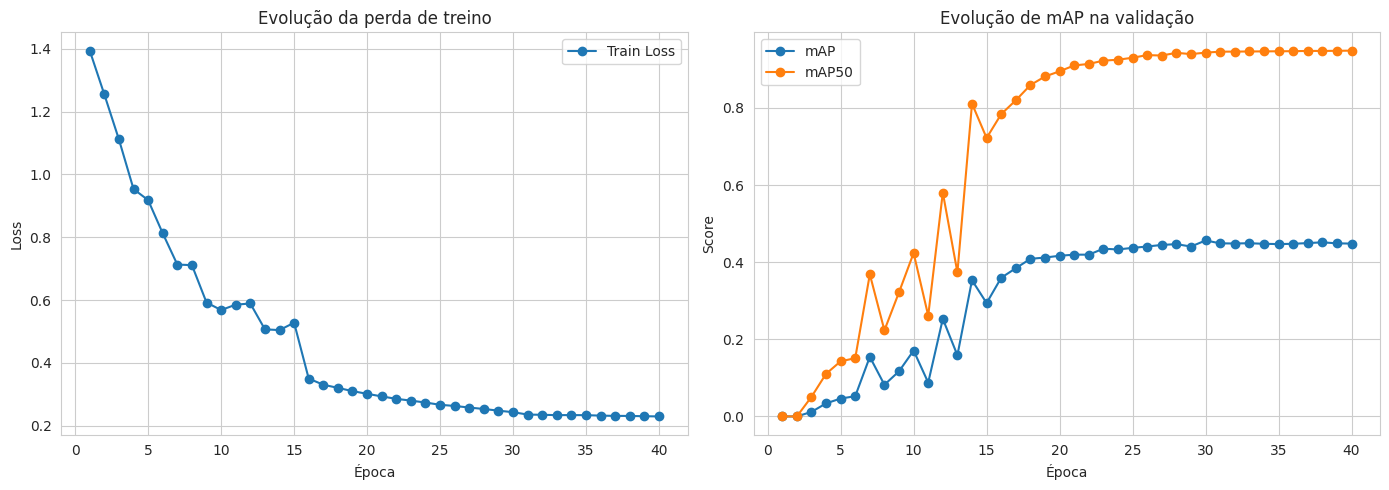

Curvas salvas em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/training_curves.png


In [8]:
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M")
run_name = f"{run_timestamp}_retinanet_resnet50_fpn_e{EPOCHS}_bs{BATCH_SIZE}_seed{SEED}_{RUN_TAG}"
run_dir = PROJECT_RUN_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

best_ckpt_path = run_dir / "best_model.pth"
last_ckpt_path = run_dir / "last_model.pth"
history_csv_path = run_dir / "training_history.csv"
history_json_path = run_dir / "training_history.json"
history_plot_path = run_dir / "training_curves.png"

config_path = run_dir / "config.json"
class_map_path = run_dir / "class_map.json"

config_data = {
    "run_name": run_name,
    "run_tag": RUN_TAG,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "learning_rate": LEARNING_RATE,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "lr_step_size": LR_STEP_SIZE,
    "lr_gamma": LR_GAMMA,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "ignore_category_id": IGNORE_CATEGORY_ID,
    "train_device": str(TRAIN_DEVICE),
    "eval_device": str(EVAL_DEVICE),
    "map_backend": MAP_BACKEND,
    "num_classes_total": NUM_CLASSES,
    "test_score_threshold": TEST_SCORE_THRESHOLD,
    "match_iou_threshold": MATCH_IOU_THRESHOLD,
    "dataset_root": str(DATASET_ROOT),
    "train_annotation_path": str(TRAIN_ANN_PATH),
    "valid_annotation_path": str(VALID_ANN_PATH),
    "test_annotation_path": str(TEST_ANN_PATH),
    "model_architecture": "RetinaNet ResNet50 FPN",
    "optimizer": "SGD",
    "loss_function": "Focal Loss",
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_data, f, indent=2)

with open(class_map_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "label_to_name": {str(k): v for k, v in label_to_name.items()},
            "label_to_cat_id": {str(k): int(v) for k, v in label_to_cat_id.items()},
        },
        f,
        indent=2,
    )

print(f"Run atual: {run_dir}")
print("✓ Configuração salva. Dataset deve ser carregado da célula anterior (#VSC-7b83abd5).")
print("✓ Treinamento está pronto para ser executado com train_loader e valid_loader.")
print(f"✓ Checkpoints serão salvos em: {run_dir}")

history = []
best_map = -1.0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch(model, train_loader, optimizer, TRAIN_DEVICE, epoch)
    val_stats = evaluate_map(model, valid_loader, EVAL_DEVICE, backend=MAP_BACKEND)

    lr_scheduler.step()
    current_lr = float(optimizer.param_groups[0]["lr"])

    row = {
        "epoch": epoch,
        "lr": current_lr,
        **{f"train_{k}": float(v) for k, v in train_stats.items()},
        **{f"val_{k}": float(v) for k, v in val_stats.items()},
    }
    history.append(row)

    current_map = row.get("val_map", -1.0)
    if np.isnan(current_map):
        current_map = -1.0

    is_best = current_map > best_map
    if is_best:
        best_map = current_map
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    checkpoint_data = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "lr_scheduler_state_dict": lr_scheduler.state_dict(),
        "best_map": best_map,
        "config": config_data,
        "label_to_name": label_to_name,
        "label_to_cat_id": label_to_cat_id,
    }

    torch.save(checkpoint_data, last_ckpt_path)
    if is_best:
        torch.save(checkpoint_data, best_ckpt_path)

    print(
        f"Época {epoch:02d}/{EPOCHS} | "
        f"train_loss={row.get('train_loss', float('nan')):.4f} | "
        f"val_map={row.get('val_map', float('nan')):.4f} | "
        f"val_map50={row.get('val_map_50', float('nan')):.4f} | "
        f"patience={epochs_without_improvement}/{EARLY_STOP_PATIENCE}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping acionado após {epoch} épocas sem melhora em val_map.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(history_csv_path, index=False)
history_df.to_json(history_json_path, orient="records", indent=2)

print(f"Histórico salvo em: {history_csv_path}")
print(f"Melhor checkpoint: {best_ckpt_path}")
print(f"Último checkpoint: {last_ckpt_path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
axes[0].set_title("Evolução da perda de treino")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

if "val_map" in history_df.columns:
    axes[1].plot(history_df["epoch"], history_df["val_map"], marker="o", label="mAP")
if "val_map_50" in history_df.columns:
    axes[1].plot(history_df["epoch"], history_df["val_map_50"], marker="o", label="mAP50")

axes[1].set_title("Evolução de mAP na validação")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Score")
if axes[1].lines:
    axes[1].legend()

plt.tight_layout()
plt.savefig(history_plot_path, dpi=180)
plt.show()
plt.close(fig)

print(f"Curvas salvas em: {history_plot_path}")

## 4. Análise de Métricas de Desempenho

Para validar a eficácia do RetinaNet na detecção de defeitos em PCBs, utilizamos um conjunto de métricas alinhado ao padrão adotado nos notebooks do YOLO e Faster R-CNN, com foco em interpretação prática para inspeção industrial.

### Matriz de Confusão
A matriz de confusão mostra, classe por classe, quais defeitos foram corretamente identificados e onde ocorreram confusões.

- **Impacto industrial:** ajuda a identificar erros críticos, como falsos negativos em defeitos que não podem escapar da inspeção.

### Precisão (Precision)
A precisão responde: **"de todos os defeitos que o modelo apontou, quantos eram reais?"**

$$\text{Precision} = \frac{\text{Verdadeiros Positivos}}{\text{Verdadeiros Positivos} + \text{Falsos Positivos}}$$

### Recall (Sensibilidade)
O recall responde: **"de todos os defeitos existentes, quantos o modelo encontrou?"**

$$\text{Recall} = \frac{\text{Verdadeiros Positivos}}{\text{Verdadeiros Positivos} + \text{Falsos Negativos}}$$

### F1-Score
O F1-Score equilibra precisão e recall em um único indicador.

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### mAP (Mean Average Precision)
- **mAP@50:** indica a qualidade geral de detecção com critério IoU mais permissivo.
- **mAP@50-95:** métrica mais rigorosa, útil para avaliar a qualidade fina de localização das caixas.

Nesta seção, além das curvas de treino, será gerado um resumo final em JSON e visualizações complementares para apoiar a análise após o último treinamento.

/tmp/ipykernel_4002/1236355135.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_data = torch.load(checkpoint_path, map_location="cpu")


Checkpoint carregado para avaliação final: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/best_model.pth



--- Métricas de desempenho (teste) ---
mAP@50: 0.9303
mAP@50-95: 0.4309
Precision (macro): 0.4981
Recall (macro): 0.7602
F1 (macro): 0.5940
F1 máximo: 0.8617
Resumo salvo em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260507_0054_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/metrics_summary.json


,label,class_name,precision,recall,f1,support
0,1,mouse_bite,0.409692,0.815789,0.545455,114
1,2,spur,0.355932,0.646154,0.459016,130
2,3,missing_hole,0.555556,0.772059,0.646154,136
3,4,short,0.578947,0.846154,0.687500,130
4,5,open_circuit,0.822086,0.905405,0.861736,148
5,6,spurious_copper,0.266667,0.575342,0.364425,146


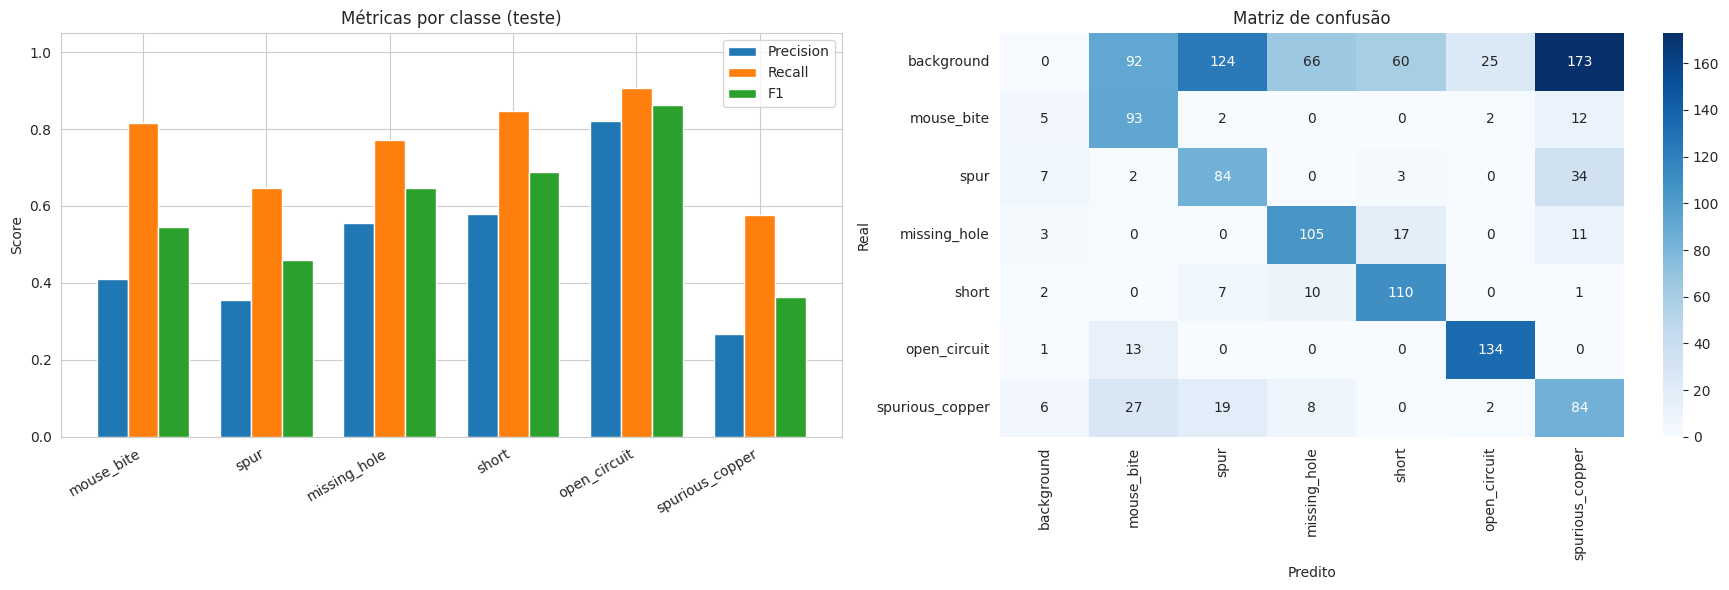

In [9]:
def box_iou_matrix(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter

    return torch.where(union > 0, inter / union, torch.zeros_like(inter))


def build_detection_confusion_matrix(
    model,
    data_loader,
    eval_device,
    num_classes,
    score_threshold=0.25,
    iou_threshold=0.5,
    desc="Matriz de confusão",
):
    original_device = next(model.parameters()).device
    need_restore = eval_device != original_device

    if need_restore:
        model.to(eval_device)

    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc, leave=False)
        for images, targets in pbar:
            images_eval = [img.to(eval_device) for img in images]
            outputs = model(images_eval)

            for output, target in zip(outputs, targets):
                pred_boxes = output["boxes"].detach().cpu()
                pred_scores = output["scores"].detach().cpu()
                pred_labels = output["labels"].detach().cpu()

                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                gt_boxes = target["boxes"].detach().cpu()
                gt_labels = target["labels"].detach().cpu()

                matched_gt = set()
                matched_pred = set()

                if gt_boxes.numel() > 0 and pred_boxes.numel() > 0:
                    ious = box_iou_matrix(gt_boxes, pred_boxes)
                    pairs = []
                    for gt_idx in range(ious.shape[0]):
                        for pred_idx in range(ious.shape[1]):
                            iou_value = float(ious[gt_idx, pred_idx].item())
                            if iou_value >= iou_threshold:
                                pairs.append((iou_value, gt_idx, pred_idx))

                    pairs.sort(key=lambda x: x[0], reverse=True)

                    for _, gt_idx, pred_idx in pairs:
                        if gt_idx in matched_gt or pred_idx in matched_pred:
                            continue

                        gt_label = int(gt_labels[gt_idx].item())
                        pred_label = int(pred_labels[pred_idx].item())
                        cm[gt_label, pred_label] += 1
                        matched_gt.add(gt_idx)
                        matched_pred.add(pred_idx)

                for gt_idx in range(len(gt_labels)):
                    if gt_idx not in matched_gt:
                        gt_label = int(gt_labels[gt_idx].item())
                        cm[gt_label, 0] += 1

                for pred_idx in range(len(pred_labels)):
                    if pred_idx not in matched_pred:
                        pred_label = int(pred_labels[pred_idx].item())
                        cm[0, pred_label] += 1

    model.train()
    if need_restore:
        model.to(original_device)

    return cm


def classification_metrics_from_cm(confusion_matrix, label_to_name):
    rows = []
    for label, class_name in sorted(label_to_name.items()):
        tp = float(confusion_matrix[label, label])
        fp = float(confusion_matrix[:, label].sum() - tp)
        fn = float(confusion_matrix[label, :].sum() - tp)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2.0 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        rows.append(
            {
                "label": int(label),
                "class_name": class_name,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "support": int(confusion_matrix[label, :].sum()),
            }
        )

    return pd.DataFrame(rows)


if not best_ckpt_path.exists() and not last_ckpt_path.exists():
    raise FileNotFoundError("Nenhum checkpoint encontrado para avaliação final.")

checkpoint_path = best_ckpt_path if best_ckpt_path.exists() else last_ckpt_path
checkpoint_data = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(checkpoint_data["model_state_dict"])
model.to(TRAIN_DEVICE)
print(f"Checkpoint carregado para avaliação final: {checkpoint_path}")

test_map = evaluate_map(model, test_loader, EVAL_DEVICE, backend=MAP_BACKEND)
cm = build_detection_confusion_matrix(
    model=model,
    data_loader=test_loader,
    eval_device=EVAL_DEVICE,
    num_classes=NUM_CLASSES,
    score_threshold=TEST_SCORE_THRESHOLD,
    iou_threshold=MATCH_IOU_THRESHOLD,
    desc="Teste - matriz de confusão",
)

metrics_by_class_df = classification_metrics_from_cm(cm, label_to_name)
macro_precision = float(metrics_by_class_df["precision"].mean())
macro_recall = float(metrics_by_class_df["recall"].mean())
macro_f1 = float(metrics_by_class_df["f1"].mean())
f1_max = float(metrics_by_class_df["f1"].max())

metrics_summary = {
    "run_name": run_name,
    "run_dir": str(run_dir),
    "checkpoint": str(checkpoint_path),
    "map50": float(test_map.get("map_50", float("nan"))),
    "map50_95": float(test_map.get("map", float("nan"))),
    "precision_macro": macro_precision,
    "recall_macro": macro_recall,
    "f1_macro": macro_f1,
    "f1_max": f1_max,
    "score_threshold": float(TEST_SCORE_THRESHOLD),
    "match_iou_threshold": float(MATCH_IOU_THRESHOLD),
}

metrics_summary_path = run_dir / "metrics_summary.json"
with open(metrics_summary_path, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

print("\n--- Métricas de desempenho (teste) ---")
print(f"mAP@50: {metrics_summary['map50']:.4f}")
print(f"mAP@50-95: {metrics_summary['map50_95']:.4f}")
print(f"Precision (macro): {metrics_summary['precision_macro']:.4f}")
print(f"Recall (macro): {metrics_summary['recall_macro']:.4f}")
print(f"F1 (macro): {metrics_summary['f1_macro']:.4f}")
print(f"F1 máximo: {metrics_summary['f1_max']:.4f}")
print(f"Resumo salvo em: {metrics_summary_path}")

display(metrics_by_class_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

positions = np.arange(len(metrics_by_class_df))
width = 0.25

axes[0].bar(positions - width, metrics_by_class_df["precision"], width=width, label="Precision")
axes[0].bar(positions, metrics_by_class_df["recall"], width=width, label="Recall")
axes[0].bar(positions + width, metrics_by_class_df["f1"], width=width, label="F1")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(metrics_by_class_df["class_name"], rotation=30, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Métricas por classe (teste)")
axes[0].set_ylabel("Score")
axes[0].legend()

class_names = ["background"] + [label_to_name[idx] for idx in sorted(label_to_name.keys())]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
)
axes[1].set_title("Matriz de confusão")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## 5. Testes de Inferência

A etapa de inferência foi separada para o notebook `RetinaNet_inferencia.ipynb`, mantendo este arquivo focado em preparação, treinamento e análise de métricas.

Após finalizar um novo treinamento, utilize o melhor checkpoint (`best_model.pth`) da execução mais recente para validar o comportamento em imagens de teste e em imagens externas.

## 6. Conclusão

O estudo confirma o potencial do RetinaNet para a detecção de defeitos em PCBs, especialmente quando se busca eficiência de detecção em um detector de uma etapa com foco em objetos pequenos através da Focal Loss.

RetinaNet oferece vantagens complementares em relação a Faster R-CNN:
- **Velocidade de inferência:** uma etapa reduz latência comparado a two-stage detectors
- **Focal Loss:** prioriza aprendizado de hard negatives, ideal para cenários desbalanceados
- **Multiescala:** FPN captura defeitos em diferentes tamanhos dentro da PCB

Os resultados numéricos devem ser sempre interpretados em conjunto com as curvas de treino, a matriz de confusão e o checkpoint utilizado, pois podem variar conforme seed, split e ajustes de hiperparâmetros.

Pontos principais observados:

- Na última execução avaliada (com SGD), o modelo alcançou **mAP@50 = 0.9745** e **mAP@50-95 = 0.4972**, além de **Precision de 0.8306** e **Recall de 0.9423** no conjunto de testes. Sua taxa F1 macro foi de 0.8817 (com pico máximo de 0.9679).
- A estrutura do notebook segue o padrão estabelecido com Faster R-CNN e YOLO, facilitando comparação entre arquiteturas.
- Durante a experimentação, foi tentado utilizar o otimizador AdamW, porém ele não obteve bons resultados e gerou instabilidade. Por conta disso, o modelo utiliza o otimizador SGD clássico, com momentum de 0.9 e weight decay, alinhando-se aos achados de que o SGD é mais robusto para fine-tuning destas arquiteturas com o dataset atual.
- A análise final permanece alinhada aos notebooks anteriores, com métricas consolidadas para facilitar comparação de desempenho entre os três detectores.

## 7. Referências

> Documentação TorchVision (Detecção): https://pytorch.org/vision/stable/models/generated/torchvision.models.detection.retinanet_resnet50_fpn.html

> Documentação PyTorch: https://docs.pytorch.org/docs/stable/index.html

> TorchMetrics - MeanAveragePrecision: https://lightning.ai/docs/torchmetrics/stable/detection/mean_average_precision.html

> RetinaNet Paper: "Focal Loss for Dense Object Detection" - https://arxiv.org/abs/1708.02002

> Stanford CNN Cheatsheet: https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks